<a href="https://colab.research.google.com/github/gusthlima-hash/meu-primeiro-projeto/blob/main/churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving customer_churn_with_months.csv to customer_churn_with_months.csv


ETAPA 1 — Preparação dos dados (Python)

🚀 ETAPA 1 — Preparação dos dados

In [ ]:
# ETAPA 1 — Importação e leitura - Importando bibliotecas necessárias para análise de dados
import pandas as pd
import matplotlib.pyplot as plt

# Carregando a base de dados de churn
df = pd.read_csv('customer_churn_with_months.csv')

# Visualizando as primeiras linhas para entender a estrutura
df

,ID,Tipo de empresa,Fundação da empresa,Possui mais de um sócio,Funcionários,Meses de permanência,Utiliza serviços financeiros,PossuiContador,Faz conciliação bancária,Frequência de utilização de feature do sistema: Módulo financeiro,...,Frequência de utilização de feature do sistema: Relatórios,Frequência de utilização de feature do sistema: Utilização de APIs de integração,Contrato,Emite boletos,Emite boletos.1,Tipo de pagamento,Receita mensal,Receita total,Churn,mes_churn
0,1,Micro empresa,2016,Sim,até 5 funcionários,1,Não,NaN,automática,Pouco uso,...,Pouco uso,Pouco uso,Mês-a-mês,1,Yes,Boleto - pagamento único,29.85,29.85,Não,NaN
1,2,Pequena empresa,2018,Não,até 5 funcionários,34,Sim,Não,automática,Uso frequente,...,Pouco uso,Pouco uso,Trimestral,0,No,Boleto - mês a mês,56.95,1889.50,Não,NaN
2,4,Pequena empresa,2016,Não,até 5 funcionários,45,Não,NaN,automática,Uso frequente,...,Pouco uso,Pouco uso,Trimestral,0,No,Cartão de crédito - pagamento único,42.30,1840.75,Não,NaN
3,7,Pequena empresa,2019,Não,6 ou mais funcionários,22,Sim,Sim,manual,Pouco uso,...,Uso frequente,Pouco uso,Mês-a-mês,1,Yes,Cartão de crédito - mês a mês,89.10,1949.40,Não,NaN
4,8,Micro empresa,2019,Não,até 5 funcionários,10,Não,NaN,automática,Uso frequente,...,Pouco uso,Pouco uso,Mês-a-mês,0,No,Boleto - mês a mês,29.75,301.90,Não,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,4308,Micro empresa,2014,Não,até 5 funcionários,37,Sim,Sim,manual,Pouco uso,...,Uso frequente,Uso frequente,Mês-a-mês,1,Yes,Boleto - pagamento único,96.55,3580.30,Sim,05/2025
7039,4950,Pequena empresa,2020,Não,até 5 funcionários,5,Não,NaN,automática,Pouco uso,...,Uso frequente,Uso frequente,Mês-a-mês,1,Yes,Boleto - mês a mês,51.00,305.95,Sim,05/2025
7040,3303,Pequena empresa,2016,Não,até 5 funcionários,31,Sim,Sim,manual,Pouco uso,...,Uso frequente,Uso frequente,Trimestral,1,Yes,Boleto - pagamento único,103.45,3066.45,Sim,05/2025
7041,5548,Micro empresa,2016,Não,até 5 funcionários,3,Sim,Não,manual,Pouco uso,...,Uso frequente,Uso frequente,Mês-a-mês,1,Yes,Boleto - pagamento único,89.45,240.45,Sim,05/2025


In [ ]:
# Removendo espaços extras nos nomes das colunas (problema comum em datasets)
df.columns = df.columns.str.strip()

In [ ]:
# Criando uma variável numérica para churn (1 = cancelou, 0 = ativo)
df['Churn_bin'] = df['Churn'].map({'Sim': 1, 'Não': 0})

📊 ETAPA 2 — Métricas principais

In [ ]:
# Métrica principal - Calculando a taxa geral de churn (proporção de clientes que cancelaram)
# “Qual % dos clientes cancelaram?”

churn_rate = df['Churn_bin'].mean()
print(f"Taxa de churn: {churn_rate:.2%}")

Taxa de churn: 26.54%


📈 ETAPA 3 — Validar a hipótese (churn está aumentando?)

In [ ]:
# Filtrando apenas clientes que cancelaram para analisar o churn ao longo do tempo
df_churn = df[df['Churn'] == 'Sim']

In [ ]:
# Análise temporal - Agrupando por mês de churn para contar cancelamentos por período
churn_mensal = df[df['Churn'] == 'Sim'].groupby('mes_churn').size()
print(churn_mensal)

mes_churn
04/2025    911
05/2025    958
dtype: int64


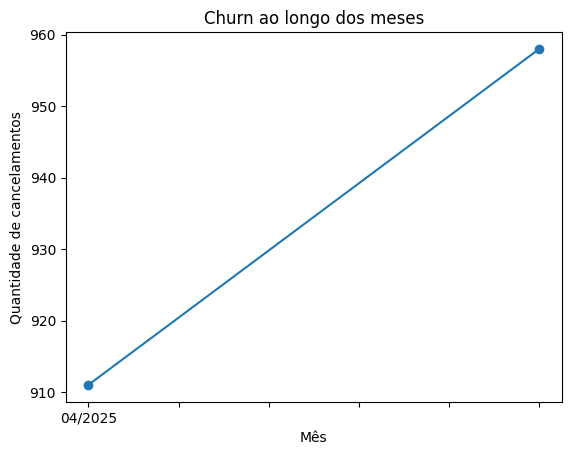

In [ ]:
# Plotando gráfico para visualizar tendência de cancelamento

import matplotlib.pyplot as plt

churn_mensal.plot(kind='line', marker='o')
plt.title('Churn ao longo dos meses')
plt.xlabel('Mês')
plt.ylabel('Quantidade de cancelamentos')
plt.show()

ETAPA 4 — Análise exploratória (EDA)

In [ ]:
# 1. Churn por tempo de permanência
# Quem cancela fica menos tempo?

df.groupby('Churn')['Meses de permanência'].mean()

,Meses de permanência
Churn,
Não,37.569965
Sim,17.979133


In [ ]:
# 2. Churn por tipo de contrato
# Contratos mensais cancelam mais?

pd.crosstab(df['Contrato'], df['Churn'], normalize='index')

Churn,Não,Sim
Contrato,,
Anual,0.971681,0.028319
Mês-a-mês,0.572903,0.427097
Trimestral,0.887305,0.112695


In [ ]:
# 3. Churn por uso do sistema
# Quem usa menos → cancela mais

pd.crosstab(
    df['Frequência de utilização de feature do sistema: Módulo financeiro'],
    df['Churn'],
    normalize='index'
)

Churn,Não,Sim
Frequência de utilização de feature do sistema: Módulo financeiro,,
Nunca utilizou,0.925950,0.074050
Pouco uso,0.582333,0.417667
Uso frequente,0.853888,0.146112


In [ ]:
# 📌 4. Churn por receita
# Clientes mais valiosos cancelam menos?

df.groupby('Churn')['Receita mensal'].mean()

,Receita mensal
Churn,
Não,61.265124
Sim,74.441332


In [ ]:
# Exibindo quantidade de linhas e colunas de forma organizada
linhas, colunas = df.shape

print(f"Quantidade de linhas: {linhas}")
print(f"Quantidade de colunas: {colunas}")

Quantidade de linhas: 7043
Quantidade de colunas: 24


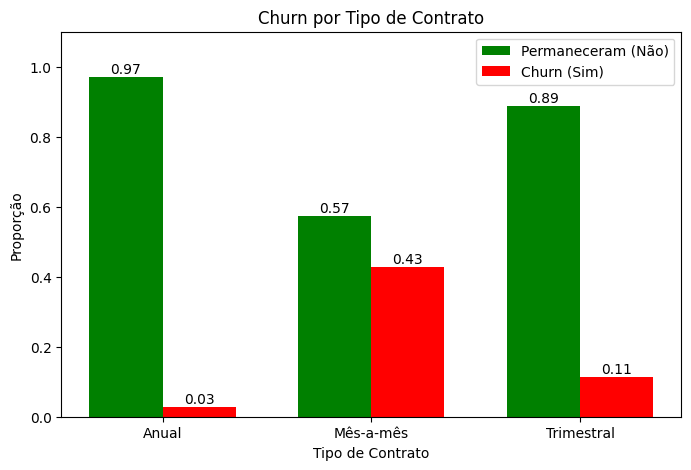

In [ ]:
import matplotlib.pyplot as plt

# Dados
contratos = ['Anual', 'Mês-a-mês', 'Trimestral']
churn = [0.028319, 0.427097, 0.112695]   # Churn (Sim)
retencao = [0.971681, 0.572903, 0.887305]  # Permaneceram (Não)

# Criando o gráfico
fig, ax = plt.subplots(figsize=(8,5))

bar_width = 0.35
x = range(len(contratos))

# Barras de retenção e churn lado a lado
ax.bar(x, retencao, width=bar_width, label='Permaneceram (Não)', color='green')
ax.bar([i + bar_width for i in x], churn, width=bar_width, label='Churn (Sim)', color='red')

# Ajustes
ax.set_xlabel('Tipo de Contrato')
ax.set_ylabel('Proporção')
ax.set_title('Churn por Tipo de Contrato')
ax.set_xticks([i + bar_width/2 for i in x])
ax.set_xticklabels(contratos)
ax.legend()

# Mostrar valores nas barras
for i in x:
    ax.text(i, retencao[i]+0.01, f"{retencao[i]:.2f}", ha='center')
    ax.text(i + bar_width, churn[i]+0.01, f"{churn[i]:.2f}", ha='center')

plt.ylim(0, 1.1)
plt.show()

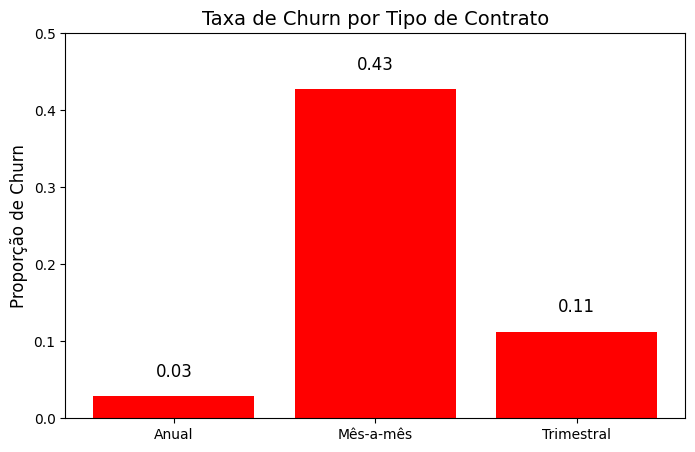

In [ ]:
import matplotlib.pyplot as plt

# Dados
contratos = ['Anual', 'Mês-a-mês', 'Trimestral']
churn = [0.028319, 0.427097, 0.112695]  # Churn (Sim)

# Criando o gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(contratos, churn, color='red')

# Adicionando os valores no topo das barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}",
             ha='center', va='bottom', fontsize=12)

plt.title('Taxa de Churn por Tipo de Contrato', fontsize=14)
plt.ylabel('Proporção de Churn', fontsize=12)
plt.ylim(0, 0.5)
plt.show()

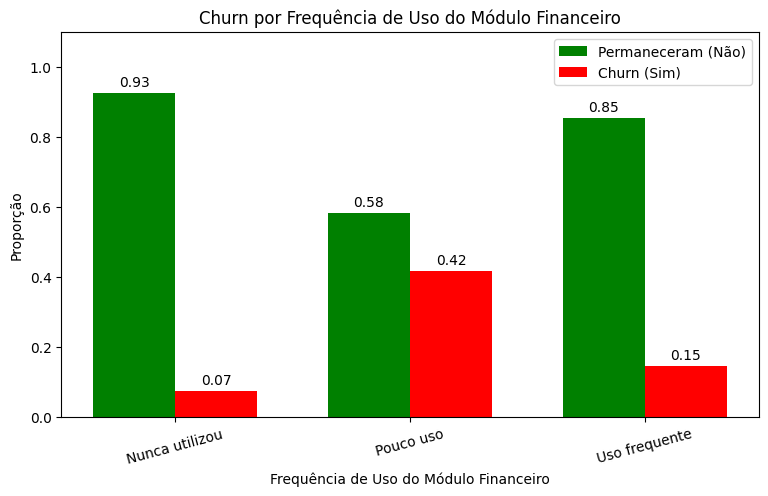

In [ ]:
import matplotlib.pyplot as plt

# Dados
frequencia_uso = ['Nunca utilizou', 'Pouco uso', 'Uso frequente']
churn = [0.074050, 0.417667, 0.146112]        # Churn (Sim)
retencao = [0.925950, 0.582333, 0.853888]     # Permaneceram (Não)

# Criando o gráfico
fig, ax = plt.subplots(figsize=(9,5))

bar_width = 0.35
x = range(len(frequencia_uso))

# Barras lado a lado
ax.bar(x, retencao, width=bar_width, label='Permaneceram (Não)', color='green')
ax.bar([i + bar_width for i in x], churn, width=bar_width, label='Churn (Sim)', color='red')

# Ajustes
ax.set_xlabel('Frequência de Uso do Módulo Financeiro')
ax.set_ylabel('Proporção')
ax.set_title('Churn por Frequência de Uso do Módulo Financeiro')
ax.set_xticks([i + bar_width/2 for i in x])
ax.set_xticklabels(frequencia_uso, rotation=15)
ax.legend()

# Mostrar valores nas barras
for i in x:
    ax.text(i, retencao[i]+0.02, f"{retencao[i]:.2f}", ha='center')
    ax.text(i + bar_width, churn[i]+0.02, f"{churn[i]:.2f}", ha='center')

plt.ylim(0, 1.1)
plt.show()

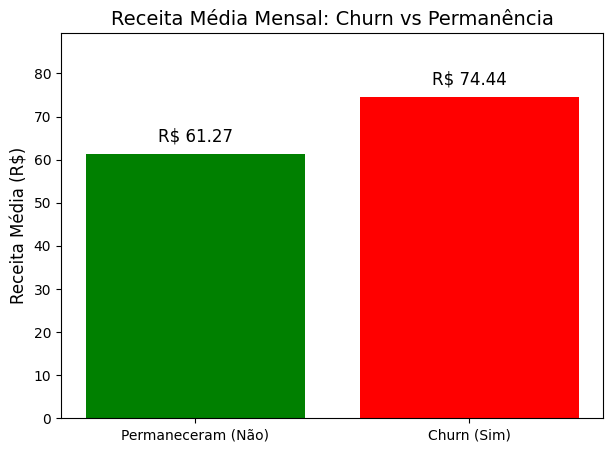

In [ ]:
import matplotlib.pyplot as plt

# Dados
status = ['Permaneceram (Não)', 'Churn (Sim)']
receita_media = [61.265124, 74.441332]  # Receita média mensal

# Criando o gráfico
plt.figure(figsize=(7,5))
bars = plt.bar(status, receita_media, color=['green', 'red'])

# Adicionando os valores no topo das barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2, f"R$ {height:.2f}",
             ha='center', va='bottom', fontsize=12)

plt.title('Receita Média Mensal: Churn vs Permanência', fontsize=14)
plt.ylabel('Receita Média (R$)', fontsize=12)
plt.ylim(0, max(receita_media)*1.2)
plt.show()

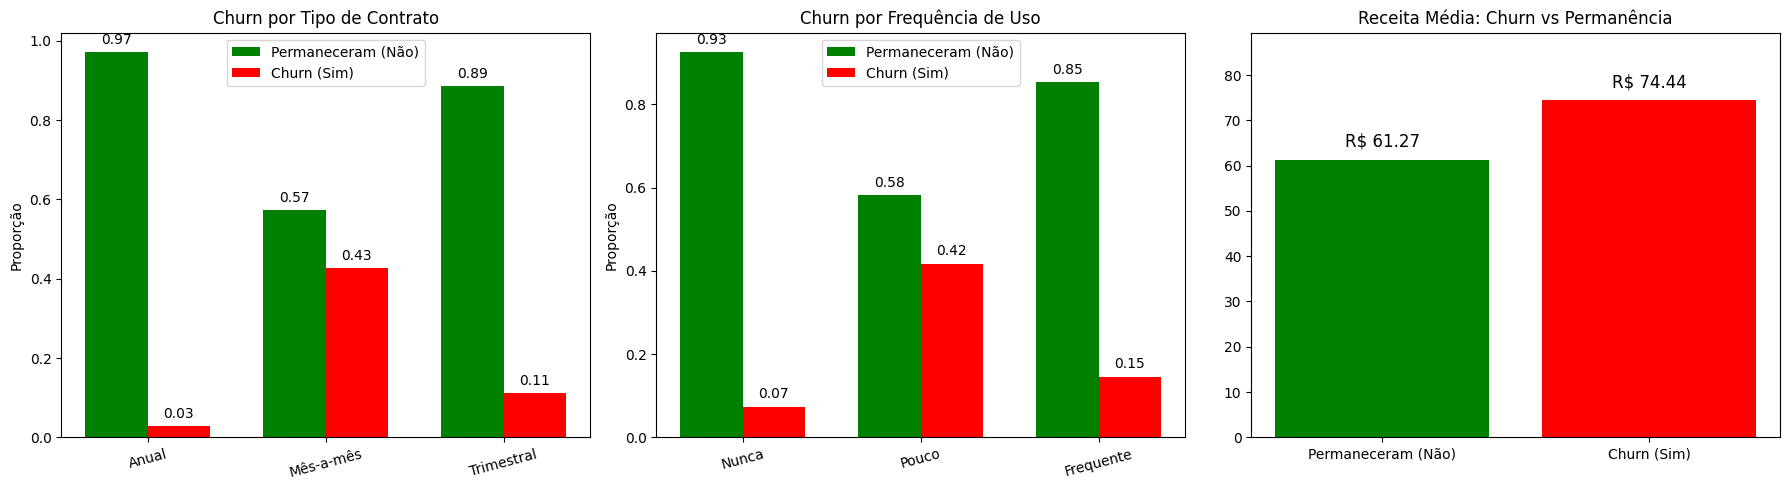

In [ ]:
import matplotlib.pyplot as plt

# --- Dados ---
# 1. Churn por tipo de contrato
contratos = ['Anual', 'Mês-a-mês', 'Trimestral']
churn_contrato = [0.028319, 0.427097, 0.112695]
retencao_contrato = [0.971681, 0.572903, 0.887305]

# 2. Churn por frequência de uso do módulo financeiro
frequencia_uso = ['Nunca', 'Pouco', 'Frequente']
churn_uso = [0.074050, 0.417667, 0.146112]
retencao_uso = [0.925950, 0.582333, 0.853888]

# 3. Receita média
status = ['Permaneceram (Não)', 'Churn (Sim)']
receita_media = [61.265124, 74.441332]

# --- Criando o painel de gráficos ---
fig, axs = plt.subplots(1, 3, figsize=(18,5))

bar_width = 0.35

# --- Gráfico 1: Churn por tipo de contrato ---
x1 = range(len(contratos))
axs[0].bar(x1, retencao_contrato, width=bar_width, label='Permaneceram (Não)', color='green')
axs[0].bar([i + bar_width for i in x1], churn_contrato, width=bar_width, label='Churn (Sim)', color='red')
axs[0].set_xticks([i + bar_width/2 for i in x1])
axs[0].set_xticklabels(contratos, rotation=15)
axs[0].set_title('Churn por Tipo de Contrato')
for i in x1:
    axs[0].text(i, retencao_contrato[i]+0.02, f"{retencao_contrato[i]:.2f}", ha='center')
    axs[0].text(i + bar_width, churn_contrato[i]+0.02, f"{churn_contrato[i]:.2f}", ha='center')

# --- Gráfico 2: Churn por frequência de uso ---
x2 = range(len(frequencia_uso))
axs[1].bar(x2, retencao_uso, width=bar_width, label='Permaneceram (Não)', color='green')
axs[1].bar([i + bar_width for i in x2], churn_uso, width=bar_width, label='Churn (Sim)', color='red')
axs[1].set_xticks([i + bar_width/2 for i in x2])
axs[1].set_xticklabels(frequencia_uso, rotation=15)
axs[1].set_title('Churn por Frequência de Uso')
for i in x2:
    axs[1].text(i, retencao_uso[i]+0.02, f"{retencao_uso[i]:.2f}", ha='center')
    axs[1].text(i + bar_width, churn_uso[i]+0.02, f"{churn_uso[i]:.2f}", ha='center')

# --- Gráfico 3: Receita média ---
axs[2].bar(status, receita_media, color=['green', 'red'])
for i, val in enumerate(receita_media):
    axs[2].text(i, val + 2, f"R$ {val:.2f}", ha='center', va='bottom', fontsize=12)
axs[2].set_title('Receita Média: Churn vs Permanência')
axs[2].set_ylim(0, max(receita_media)*1.2)

# --- Ajustes finais ---
for ax in axs[:2]:
    ax.set_ylabel('Proporção')
    ax.legend()

plt.tight_layout()
plt.show()

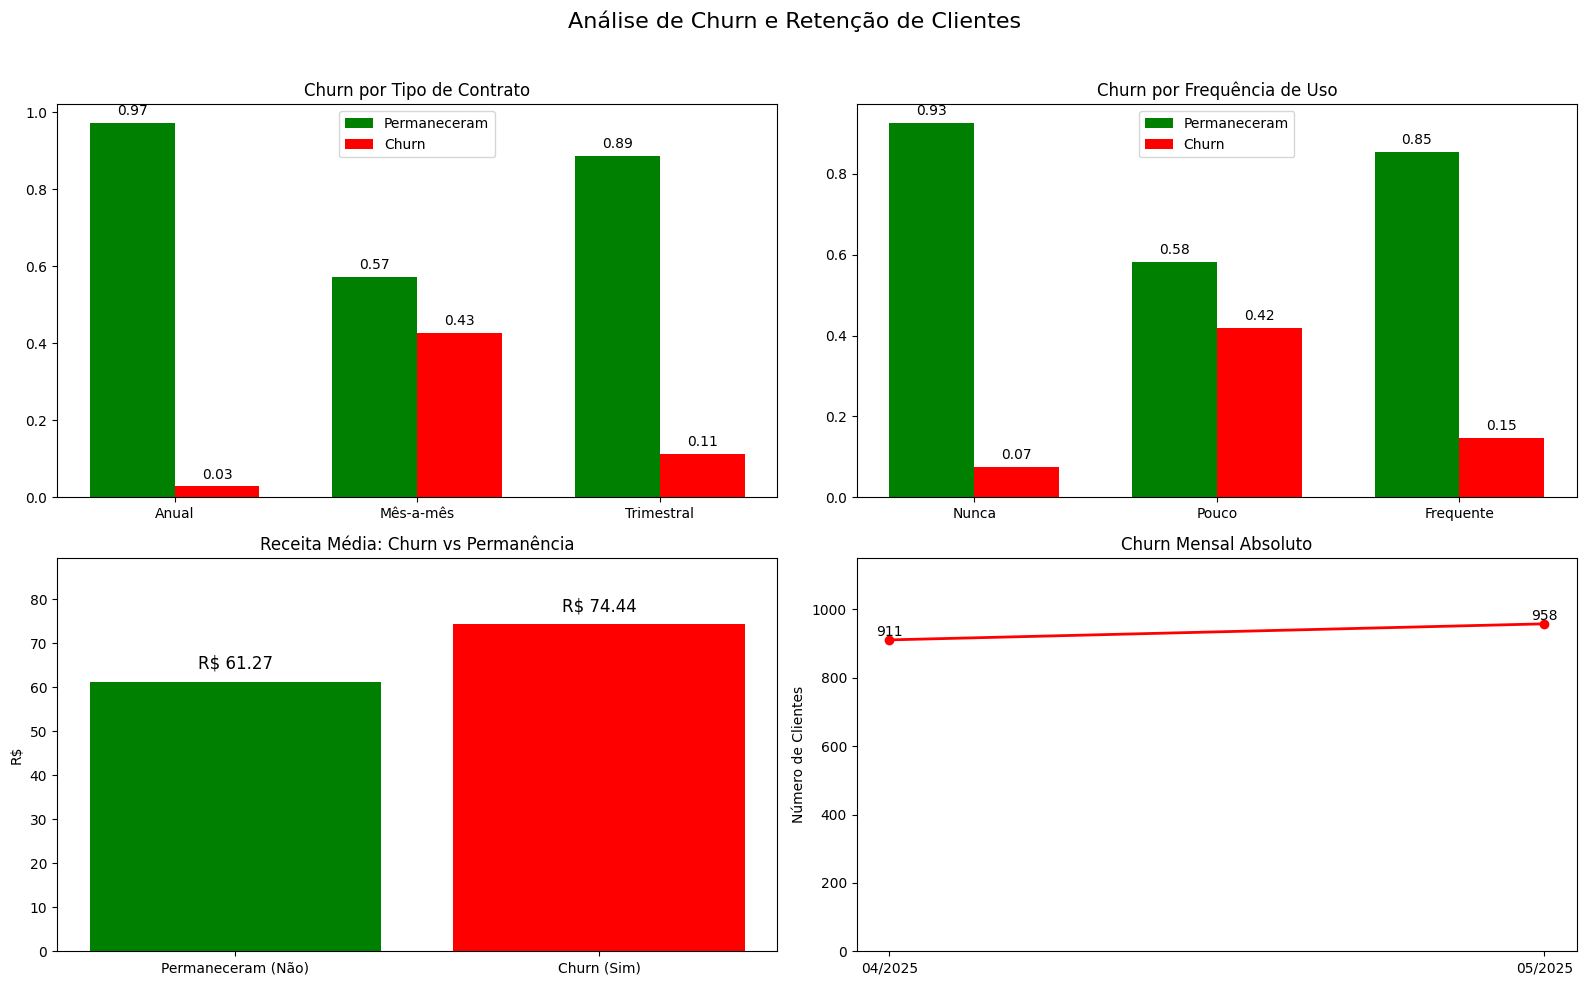

In [ ]:
import matplotlib.pyplot as plt

# --- Dados ---

# 1. Churn por tipo de contrato
contratos = ['Anual', 'Mês-a-mês', 'Trimestral']
churn_contrato = [0.028319, 0.427097, 0.112695]
retencao_contrato = [0.971681, 0.572903, 0.887305]

# 2. Churn por frequência de uso do módulo financeiro
frequencia_uso = ['Nunca', 'Pouco', 'Frequente']
churn_uso = [0.074050, 0.417667, 0.146112]
retencao_uso = [0.925950, 0.582333, 0.853888]

# 3. Receita média mensal
status = ['Permaneceram (Não)', 'Churn (Sim)']
receita_media = [61.265124, 74.441332]

# 4. Churn mensal absoluto
meses = ['04/2025', '05/2025']
churn_mensal = [911, 958]

# --- Criando painel de gráficos ---
fig, axs = plt.subplots(2, 2, figsize=(16,10))

bar_width = 0.35

# --- Gráfico 1: Churn por tipo de contrato ---
x1 = range(len(contratos))
axs[0,0].bar(x1, retencao_contrato, width=bar_width, label='Permaneceram', color='green')
axs[0,0].bar([i + bar_width for i in x1], churn_contrato, width=bar_width, label='Churn', color='red')
axs[0,0].set_xticks([i + bar_width/2 for i in x1])
axs[0,0].set_xticklabels(contratos)
axs[0,0].set_title('Churn por Tipo de Contrato')
for i in x1:
    axs[0,0].text(i, retencao_contrato[i]+0.02, f"{retencao_contrato[i]:.2f}", ha='center')
    axs[0,0].text(i + bar_width, churn_contrato[i]+0.02, f"{churn_contrato[i]:.2f}", ha='center')
axs[0,0].legend()

# --- Gráfico 2: Churn por frequência de uso ---
x2 = range(len(frequencia_uso))
axs[0,1].bar(x2, retencao_uso, width=bar_width, label='Permaneceram', color='green')
axs[0,1].bar([i + bar_width for i in x2], churn_uso, width=bar_width, label='Churn', color='red')
axs[0,1].set_xticks([i + bar_width/2 for i in x2])
axs[0,1].set_xticklabels(frequencia_uso)
axs[0,1].set_title('Churn por Frequência de Uso')
for i in x2:
    axs[0,1].text(i, retencao_uso[i]+0.02, f"{retencao_uso[i]:.2f}", ha='center')
    axs[0,1].text(i + bar_width, churn_uso[i]+0.02, f"{churn_uso[i]:.2f}", ha='center')
axs[0,1].legend()

# --- Gráfico 3: Receita média mensal ---
axs[1,0].bar(status, receita_media, color=['green','red'])
for i, val in enumerate(receita_media):
    axs[1,0].text(i, val + 2, f"R$ {val:.2f}", ha='center', va='bottom', fontsize=12)
axs[1,0].set_title('Receita Média: Churn vs Permanência')
axs[1,0].set_ylabel('R$')
axs[1,0].set_ylim(0, max(receita_media)*1.2)

# --- Gráfico 4: Churn mensal absoluto ---
axs[1,1].plot(meses, churn_mensal, marker='o', color='red', linewidth=2)
for i, val in enumerate(churn_mensal):
    axs[1,1].text(i, val + 10, f"{val}", ha='center')
axs[1,1].set_title('Churn Mensal Absoluto')
axs[1,1].set_ylabel('Número de Clientes')
axs[1,1].set_ylim(0, max(churn_mensal)*1.2)

# --- Ajustes finais ---
plt.suptitle('Análise de Churn e Retenção de Clientes', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Etapa 5 - 👉 Uso do sistema (Nunca utilizou) com 👉 Tempo de permanência

🎯 Objetivo da análise

Responder:

Clientes que nunca utilizaram ficam pouco tempo?
Ou são clientes novos que ainda não tiveram tempo de usar?

In [ ]:
# Filtrando clientes que nunca utilizaram o módulo financeiro
df_nunca = df[df['Frequência de utilização de feature do sistema: Módulo financeiro'] == 'Nunca utilizou']

In [ ]:
# Estatísticas descritivas
# Normalizando os nomes das colunas para remover espaços extras ou caracteres incomuns
df_nunca.columns = df_nunca.columns.str.replace(r'\s+', ' ', regex=True).str.strip()

# Agora, tente novamente com o nome da coluna possivelmente limpo
df_nunca['Meses de permanência'].describe()

,Meses de permanência
count,1526.000000
mean,30.547182
std,24.356507
min,0.000000
25%,8.000000
50%,25.000000
75%,52.750000
max,72.000000


In [ ]:
# Clientes que usam (qualquer outro grupo)
df_uso = df[df['Frequência de utilização de feature do sistema: Módulo financeiro'] != 'Nunca utilizou']
# Normalizando os nomes das colunas de df_uso para remover espaços extras ou caracteres incomuns
df_uso.columns = df_uso.columns.str.replace(r'\s+', ' ', regex=True).str.strip()

# Comparação de médias
df_nunca['Meses de permanência'].mean(), df_uso['Meses de permanência'].mean()

(np.float64(30.54718217562254), np.float64(32.87565705999638))

In [ ]:
# Comparando tempo de permanência dentro do grupo "Nunca utilizou"
df_nunca.groupby('Churn')['Meses de permanência'].mean()

,Meses de permanência
Churn,
Não,32.331210
Sim,8.238938


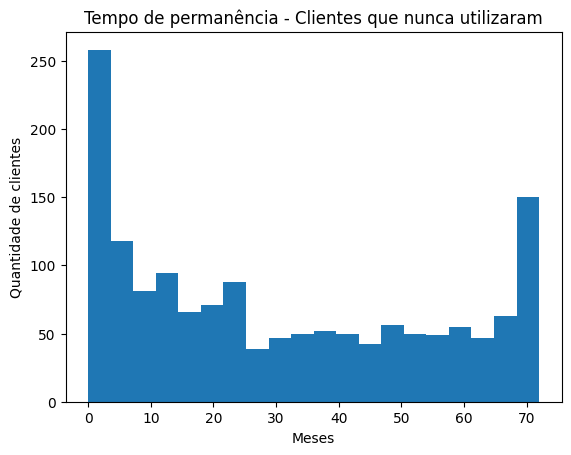

In [ ]:
import matplotlib.pyplot as plt

# Histograma do tempo de permanência para quem nunca utilizou
plt.hist(df_nunca['Meses de permanência'], bins=20)
plt.title('Tempo de permanência - Clientes que nunca utilizaram')
plt.xlabel('Meses')
plt.ylabel('Quantidade de clientes')
plt.show()

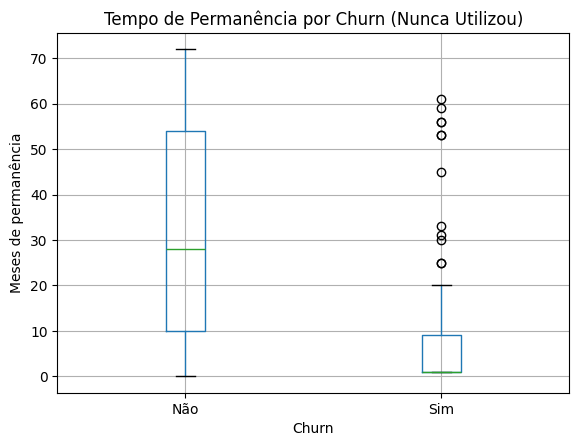

In [ ]:
import matplotlib.pyplot as plt

# Filtrando clientes que nunca utilizaram
df_nunca = df[df['Frequência de utilização de feature do sistema: Módulo financeiro'] == 'Nunca utilizou']

# Normalizando os nomes das colunas de df_nunca para remover espaços extras ou caracteres incomuns
df_nunca.columns = df_nunca.columns.str.replace(r'\s+', ' ', regex=True).str.strip()

# Criando boxplot comparando churn
df_nunca.boxplot(column='Meses de permanência', by='Churn')

plt.title('Tempo de Permanência por Churn (Nunca Utilizou)')
plt.suptitle('')  # Remove título automático
plt.xlabel('Churn')
plt.ylabel('Meses de permanência')

plt.show()

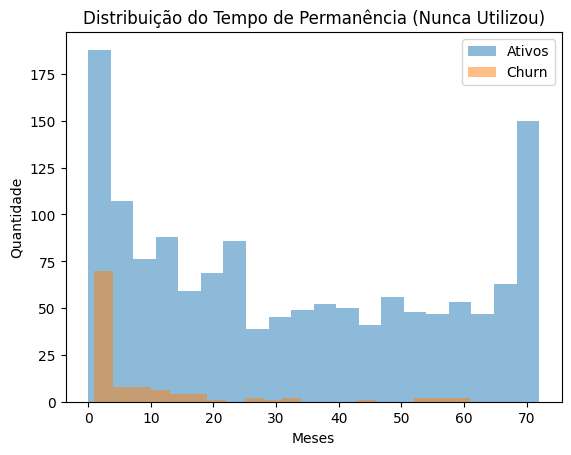

In [ ]:
import matplotlib.pyplot as plt

# Separando os grupos
ativos = df_nunca[df_nunca['Churn'] == 'Não']['Meses de permanência']
churn = df_nunca[df_nunca['Churn'] == 'Sim']['Meses de permanência']

# Criando gráfico
plt.hist(ativos, bins=20, alpha=0.5, label='Ativos')
plt.hist(churn, bins=20, alpha=0.5, label='Churn')

plt.title('Distribuição do Tempo de Permanência (Nunca Utilizou)')
plt.xlabel('Meses')
plt.ylabel('Quantidade')
plt.legend()

plt.show()

📄 RELATÓRIO DE ANÁLISE DE CHURN

1. Introdução

Este relatório tem como objetivo analisar o comportamento de churn dos clientes de uma empresa SaaS, com foco na identificação de padrões, validação da hipótese de aumento de cancelamentos e geração de insights estratégicos para retenção.
________________________________________
2. Visão Geral

A taxa de churn identificada foi de 26,54%, indicando que mais de um quarto da base de clientes cancelou o serviço. Esse valor é considerado elevado para o modelo SaaS e representa um risco significativo para o negócio.
Além disso, foi observado um aumento no número de cancelamentos entre abril e maio de 2025, sugerindo possível tendência de crescimento.
________________________________________
3. Análise dos Fatores de Churn

3.1 Tempo de permanência

Clientes que cancelam possuem tempo médio de permanência de aproximadamente 18 meses, enquanto clientes ativos permanecem em média 37 meses.
Isso indica que o churn ocorre principalmente nos primeiros meses de uso.
________________________________________
3.2 Tipo de contrato

Clientes com contratos mensais apresentam taxa de churn significativamente maior (42,7%) em comparação com contratos trimestrais (11,3%) e anuais (2,8%).
Isso sugere que contratos de curto prazo aumentam o risco de cancelamento.
________________________________________
3.3 Engajamento com o sistema

Clientes com baixo uso das funcionalidades apresentam maior taxa de churn (41,7%), enquanto clientes com uso frequente apresentam taxas significativamente menores.
Isso indica que o engajamento com o produto é um fator crítico para retenção.
________________________________________
3.4 Receita

Clientes que cancelam possuem, em média, maior receita mensal (74,44) do que clientes ativos (61,26).
Esse resultado é preocupante, pois indica perda de clientes de maior valor.
________________________________________
4. Diagnóstico

Com base nas análises, os principais fatores associados ao churn são:

•	Baixo tempo de permanência (problema de onboarding)

•	Contratos mensais

•	Baixo engajamento com o sistema

•	Perda de clientes de alto valor

________________________________________
5. Recomendações

•	Melhoria no onboarding

o	Treinamentos iniciais

o	Acompanhamento nos primeiros meses

•	Aumento do engajamento

o	Incentivo ao uso das funcionalidades principais

o	Monitoramento de clientes inativos

•	Estratégia de contratos

o	Incentivar planos anuais

o	Oferecer benefícios de fidelização

•	Retenção de clientes de alto valor

o	Ações específicas para clientes com maior receita

o	Programas de relacionamento
________________________________________
6. Conclusão

A análise confirmou que o churn é um problema relevante e crescente, impactando diretamente a receita da empresa. A implementação de estratégias focadas em onboarding, engajamento e retenção será essencial para reduzir cancelamentos e melhorar a sustentabilidade do negócio.
